In [36]:
import umap.umap_ as umap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import random
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
import scipy.stats as stats
import math
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [4]:
data = pd.read_csv('edited_data.csv')
data[data < 0] = 0
data["date"] = pd.to_datetime(data["Date"], format="%Y%m%d")
data["Month"] = data["date"].dt.month
data['TRAFFIC'] = data['TRAFFIC'].map(
    lambda x: math.log(x) if (pd.notnull(x) and x > 0) else x
)
# data['Vehicles'] = data['Vehicles'].map(
#     lambda x: math.log(x) if (pd.notnull(x) and x > 0) else x
# )
# data['SNOW_DAY_SUM'] = data['SNOW_DAY_SUM'].map(
#     lambda x: math.log(x) if (pd.notnull(x) and x > 0) else x
# )
data.head()

,Unnamed: 0,Date,Direction,Time,TRAFFIC,PRCP,SNOW,SNWD,SNOW_DAY_SUM,Vehicles,Driver Age,Condition_Code,MorF,DayOfWeek,date,Month
0,0,20140101,1,0,4.624973,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
1,1,20140101,0,0,4.875197,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
2,2,20140101,1,1,4.510860,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
3,3,20140101,0,1,5.087596,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
4,4,20140101,1,2,4.454347,0.12,1.9,13.0,1.9,1.0,26.0,0.0,0.0,3,2014-01-01,1


In [5]:
# data['TRAFFIC'] = data['TRAFFIC'].map(
#     lambda x: math.log(x) if (pd.notnull(x) and x > 0) else x
# )
# data['Vehicles'] = data['Vehicles'].map(
#     lambda x: math.log(x) if (pd.notnull(x) and x > 0) else x
# )

In [6]:
data_with_snow_day_sum = data[data['SNOW_DAY_SUM'] > 0]
data_with_snow_vehicle = data_with_snow_day_sum[data_with_snow_day_sum['Vehicles'] > 0]

In [7]:
data_with_snow_no_vehicle = data_with_snow_day_sum[data_with_snow_day_sum['Vehicles'] == 0]

In [8]:
data_with_snow_vehicle["Time"] = data_with_snow_vehicle["Time"].astype("category")
data_with_snow_vehicle["Month"] = data_with_snow_vehicle["Month"].astype("category")
data_with_snow_vehicle["DayOfWeek"] = data_with_snow_vehicle["DayOfWeek"].astype("category")

data_with_snow_no_vehicle["Time"] = data_with_snow_no_vehicle["Time"].astype("category")
data_with_snow_no_vehicle["Month"] = data_with_snow_no_vehicle["Month"].astype("category")
data_with_snow_no_vehicle["DayOfWeek"] = data_with_snow_no_vehicle["DayOfWeek"].astype("category")

C:\Users\wsach\AppData\Local\Temp\ipykernel_22468\1869111708.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_with_snow_vehicle["Time"] = data_with_snow_vehicle["Time"].astype("category")
C:\Users\wsach\AppData\Local\Temp\ipykernel_22468\1869111708.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_with_snow_vehicle["Month"] = data_with_snow_vehicle["Month"].astype("category")
C:\Users\wsach\AppData\Local\Temp\ipykernel_22468\1869111708.py:3: SettingWithCopyWarning: 
A value is trying to be se

In [9]:
ols_vehicle = smf.ols(
    formula="TRAFFIC ~ C(Time) + C(Month, Sum) + C(DayOfWeek) + SNOW_DAY_SUM + Vehicles",
    data=data_with_snow_vehicle
).fit()

print(ols_vehicle.summary())

                            OLS Regression Results                            
Dep. Variable:                TRAFFIC   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     433.3
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:01:18   Log-Likelihood:                -3838.7
No. Observations:                5643   AIC:                             7761.
Df Residuals:                    5601   BIC:                             8040.
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               4.8622    

In [10]:
ols_no_vehicle = smf.ols(
    formula="TRAFFIC ~ C(Time) + C(Month, Sum) + C(DayOfWeek) + SNOW_DAY_SUM",
    data=data_with_snow_no_vehicle
).fit()

print(ols_no_vehicle.summary())

                            OLS Regression Results                            
Dep. Variable:                TRAFFIC   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                 1.372e+04
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:01:19   Log-Likelihood:                -49851.
No. Observations:               85637   AIC:                         9.978e+04
Df Residuals:                   85596   BIC:                         1.002e+05
Df Model:                          40                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               4.9018    

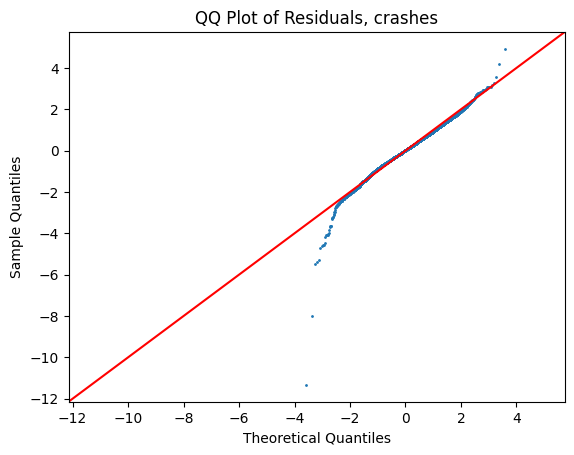

In [11]:
sm.qqplot(ols_vehicle.get_influence().resid_studentized_internal, line='45', scale=1, markersize=1)
plt.title("QQ Plot of Residuals, crashes")
plt.show()

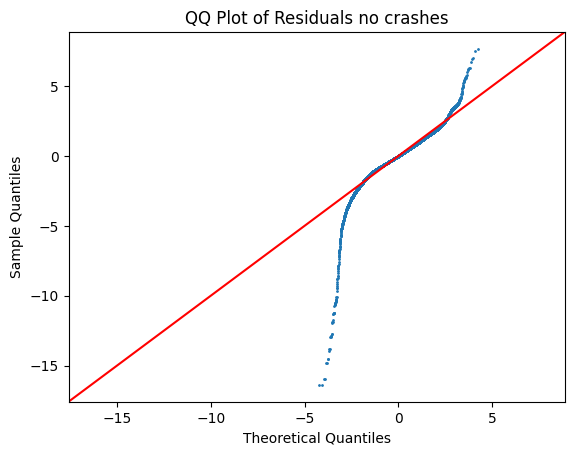

In [12]:
sm.qqplot(ols_no_vehicle.get_influence().resid_studentized_internal, line='45', scale=1, markersize=1)
plt.title("QQ Plot of Residuals no crashes")
plt.show()

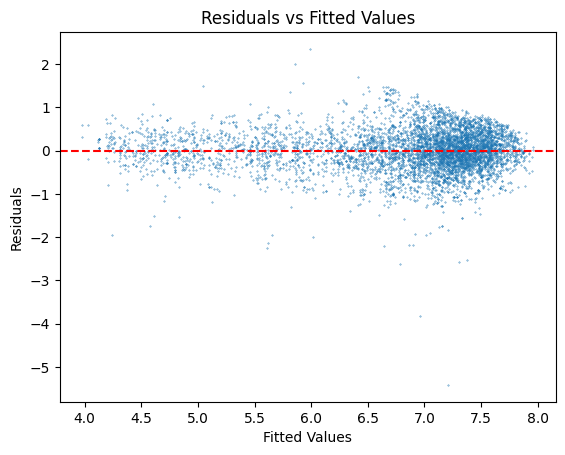

In [13]:
plt.scatter(ols_vehicle.fittedvalues, ols_vehicle.resid, s=0.1)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

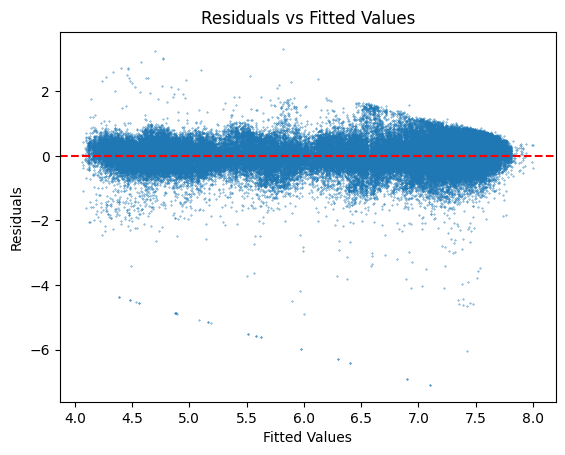

In [14]:
plt.scatter(ols_no_vehicle.fittedvalues, ols_no_vehicle.resid, s=0.1)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

In [15]:
Month_codots = {
        1: 3, 2:1, 3:2, 4:4, 12: 5, 5:6, 11: 7, 6: 8, 7: 12, 8: 10, 9: 11, 10: 9
    }
data_with_snow_vehicle['WeightedMonth'] = data_with_snow_vehicle['Month'].map(lambda x: Month_codots[x])
data_with_snow_vehicle.head()

C:\Users\wsach\AppData\Local\Temp\ipykernel_22468\2259182447.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_with_snow_vehicle['WeightedMonth'] = data_with_snow_vehicle['Month'].map(lambda x: Month_codots[x])


,Unnamed: 0,Date,Direction,Time,TRAFFIC,PRCP,SNOW,SNWD,SNOW_DAY_SUM,Vehicles,Driver Age,Condition_Code,MorF,DayOfWeek,date,Month,WeightedMonth
4,4,20140101,1,2,4.454347,0.12,1.9,13.0,1.9,1.0,26.0,0.0,0.0,3,2014-01-01,1,3
5,5,20140101,0,2,5.030438,0.12,1.9,13.0,1.9,1.0,26.0,0.0,0.0,3,2014-01-01,1,3
16,16,20140101,1,8,6.495266,0.12,1.9,13.0,1.9,2.0,17.0,6.0,1.0,3,2014-01-01,1,3
17,17,20140101,0,8,7.785305,0.12,1.9,13.0,1.9,2.0,17.0,6.0,1.0,3,2014-01-01,1,3
20,20,20140101,1,10,7.275172,0.12,1.9,13.0,1.9,2.0,29.0,6.0,0.0,3,2014-01-01,1,3


In [16]:
ols_vehicle_weight = smf.ols(
    formula="TRAFFIC ~ C(Time) + C(Month, Sum) + C(DayOfWeek) + SNOW_DAY_SUM + Vehicles",
    data=data_with_snow_vehicle
).fit()

print(ols_vehicle_weight.summary())

                            OLS Regression Results                            
Dep. Variable:                TRAFFIC   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     433.3
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:01:20   Log-Likelihood:                -3838.7
No. Observations:                5643   AIC:                             7761.
Df Residuals:                    5601   BIC:                             8040.
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               4.8622    

#### Test for importance of variables

In [20]:
data_with_snow_no_vehicle.head()

,Unnamed: 0,Date,Direction,Time,TRAFFIC,PRCP,SNOW,SNWD,SNOW_DAY_SUM,Vehicles,Driver Age,Condition_Code,MorF,DayOfWeek,date,Month
0,0,20140101,1,0,4.624973,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
1,1,20140101,0,0,4.875197,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
2,2,20140101,1,1,4.510860,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
3,3,20140101,0,1,5.087596,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
6,6,20140101,1,3,3.912023,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1


In [24]:
data_with_snow_no_vehicle_ploter = data_with_snow_no_vehicle.drop(columns={'date', 'Date', 'Unnamed: 0', 'Driver Age', 'Condition_Code', 'MorF', 'Vehicles'})

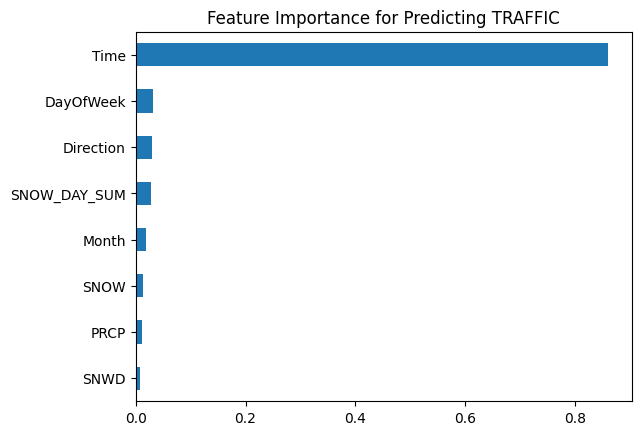

In [25]:
X = data_with_snow_no_vehicle_ploter.drop('TRAFFIC', axis=1)
X = X.apply(lambda col: col.fillna(-1) if col.dtype != 'category' else col)
y = data_with_snow_no_vehicle_ploter['TRAFFIC']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor()
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance for Predicting TRAFFIC')
plt.show()

In [26]:
data_with_snow_vehicle_ploter = data_with_snow_vehicle.drop(columns={'date', 'Date', 'Unnamed: 0'})

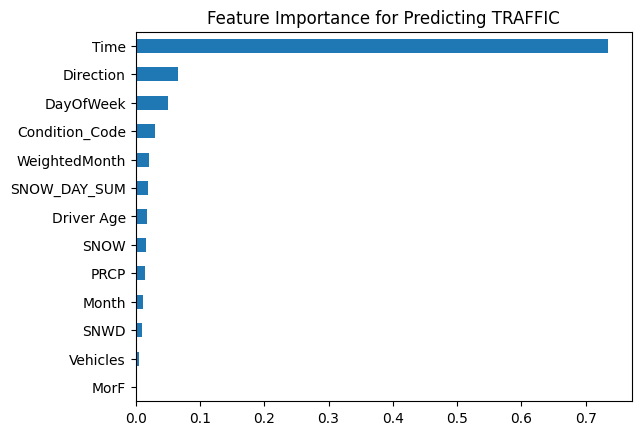

In [27]:
X = data_with_snow_vehicle_ploter.drop('TRAFFIC', axis=1)
X = X.apply(lambda col: col.fillna(-1) if col.dtype != 'category' else col)
y = data_with_snow_vehicle_ploter['TRAFFIC']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor()
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance for Predicting TRAFFIC')
plt.show()

In [31]:
ols_vehicle_weight_2 = smf.ols(
    formula="TRAFFIC ~ C(Time) + C(WeightedMonth) + C(DayOfWeek) + SNOW_DAY_SUM + C(Condition_Code) + C(Direction) + SNOW",
    data=data_with_snow_vehicle
).fit()

print(ols_vehicle_weight_2.summary())

                            OLS Regression Results                            
Dep. Variable:                TRAFFIC   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     401.8
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:30:35   Log-Likelihood:                -3567.4
No. Observations:                5643   AIC:                             7237.
Df Residuals:                    5592   BIC:                             7575.
Df Model:                          50                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

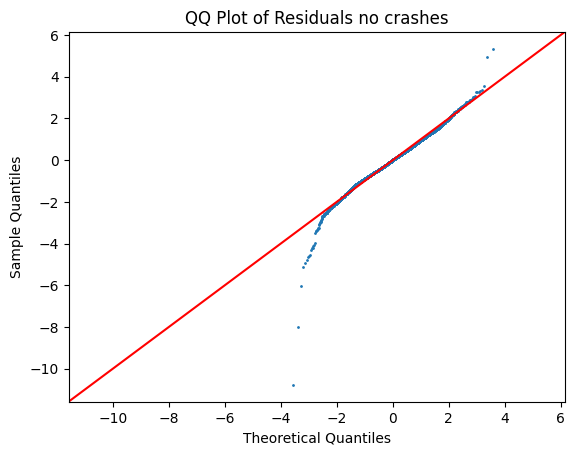

In [33]:
sm.qqplot(ols_vehicle_weight_2.get_influence().resid_studentized_internal, line='45', scale=1, markersize=1)
plt.title("QQ Plot of Residuals no crashes")
plt.show()

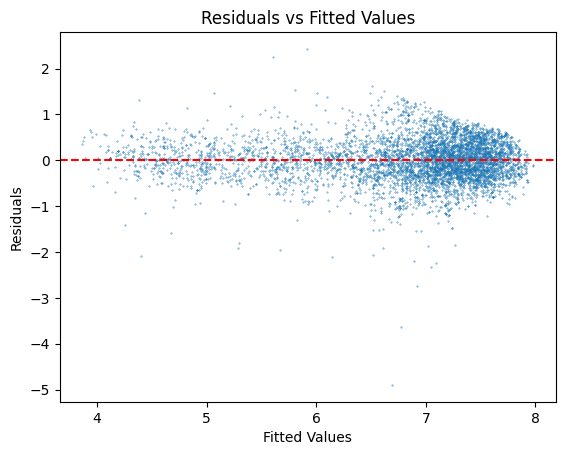

In [32]:
plt.scatter(ols_vehicle_weight_2.fittedvalues, ols_vehicle_weight_2.resid, s=0.1)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

<Figure size 10000x10000 with 0 Axes>

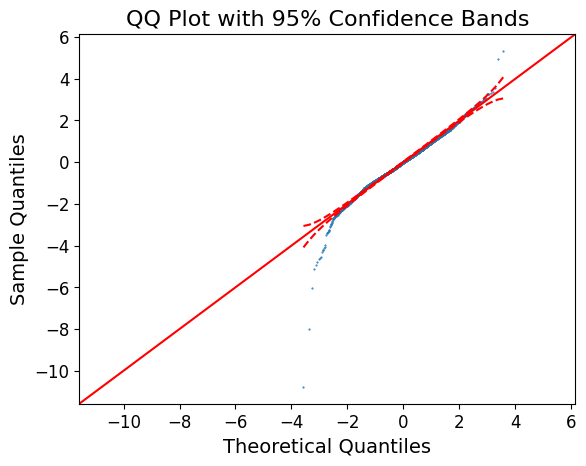

In [44]:
resid = ols_vehicle_weight_2.get_influence().resid_studentized_internal
n = len(resid)


quantiles = np.linspace(0, 1, n+2)[1:-1]
theoretical_q = stats.norm.ppf(quantiles)

pdf_vals = stats.norm.pdf(theoretical_q)
var_q = quantiles * (1 - quantiles) / (n * pdf_vals**2)
se_q = np.sqrt(var_q)
z = stats.norm.ppf(0.975)
lower = theoretical_q - z * se_q
upper = theoretical_q + z * se_q

plt.figure(figsize=(100,100)) 

sm.qqplot(resid, line='45', markersize=0.5)
plt.plot(theoretical_q, lower, 'r--', linewidth=1.5)
plt.plot(theoretical_q, upper, 'r--', linewidth=1.5)

plt.title("QQ Plot with 95% Confidence Bands", fontsize=16)
plt.xlabel("Theoretical Quantiles", fontsize=14)
plt.ylabel("Sample Quantiles", fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)

plt.show()